Model


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#STEP 1 - LOAD DATA
df = pd.read_csv('cleaned_depression_data.csv')
print(f"Shape: {df.shape}")


Shape: (27790, 12)


In [3]:
##Logistic Regression
# STEP 2 - SPLIT FEATURES AND TARGET
print("\n" + "=" * 50)
print("STEP 2 - SPLIT FEATURES AND TARGET")

print("=" * 50)
X = df.drop(columns=['Depression'])
y = df['Depression']
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# STEP 3 - SPLIT TRAIN AND TEST
print("\n" + "=" * 50)
print("STEP 3 - SPLIT TRAIN AND TEST")
print("=" * 50)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"Training size: {X_train.shape}")
print(f"Testing size: {X_test.shape}")

# STEP 4 - BUILD MODEL
print("\n" + "=" * 50)
print("STEP 4 - BUILD MODEL")
print("=" * 50)
model = LogisticRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")

# STEP 5 - EVALUATE MODEL
print("\n" + "=" * 50)
print("STEP 5 - EVALUATE MODEL")
print("=" * 50)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


STEP 2 - SPLIT FEATURES AND TARGET
Features shape: (27790, 11)
Target shape: (27790,)

STEP 3 - SPLIT TRAIN AND TEST
Training size: (22232, 11)
Testing size: (5558, 11)

STEP 4 - BUILD MODEL
Model trained successfully!

STEP 5 - EVALUATE MODEL
Accuracy: 83.56%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79      2263
           1       0.85      0.87      0.86      3295

    accuracy                           0.84      5558
   macro avg       0.83      0.83      0.83      5558
weighted avg       0.83      0.84      0.83      5558


Confusion Matrix:
[[1761  502]
 [ 412 2883]]


In [ ]:
#Wag irun nag test lang ako ng ibang machine learning algo 
from sklearn.ensemble import RandomForestClassifier

print("=" * 50)
print("RANDOM FOREST MODEL")
print("=" * 50)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Accuracy: {rf_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

RANDOM FOREST MODEL
Accuracy: 82.66%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.78      2263
           1       0.85      0.86      0.86      3295

    accuracy                           0.83      5558
   macro avg       0.82      0.82      0.82      5558
weighted avg       0.83      0.83      0.83      5558


Confusion Matrix:
[[1748  515]
 [ 449 2846]]


In [ ]:
#Wag irun nag test lang ako ng ibang machine learning algo 

from sklearn.naive_bayes import GaussianNB

print("=" * 50)
print("NAIVE BAYES MODEL")
print("=" * 50)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)
print(f"Accuracy: {nb_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, nb_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nb_pred))

NAIVE BAYES MODEL
Accuracy: 82.98%

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.79      2263
           1       0.86      0.85      0.86      3295

    accuracy                           0.83      5558
   macro avg       0.82      0.82      0.82      5558
weighted avg       0.83      0.83      0.83      5558


Confusion Matrix:
[[1802  461]
 [ 485 2810]]


CONFUSION MATRIX VISUALIZATION


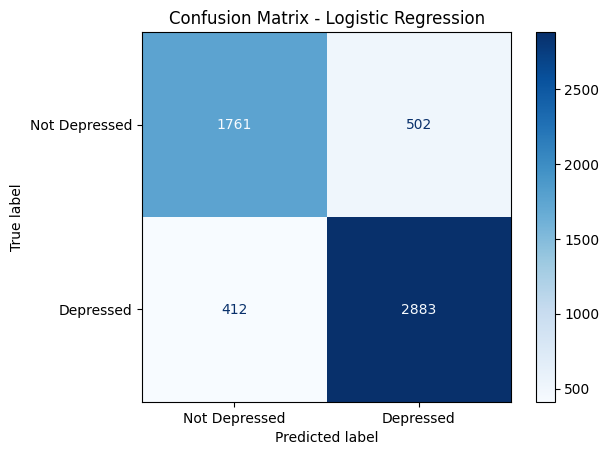

MODEL COMPARISON


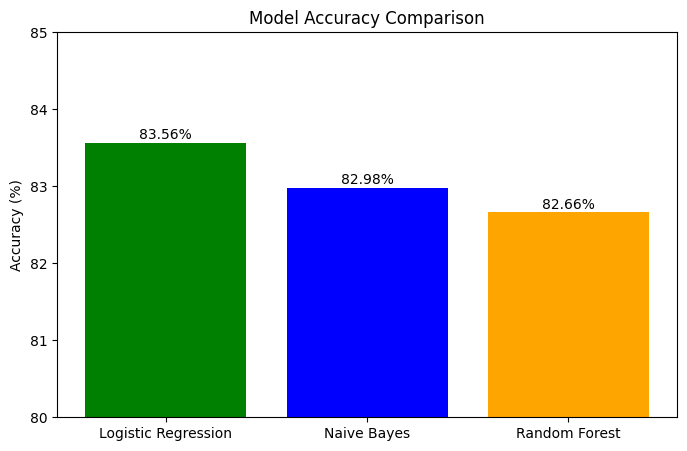

FEATURE IMPORTANCE


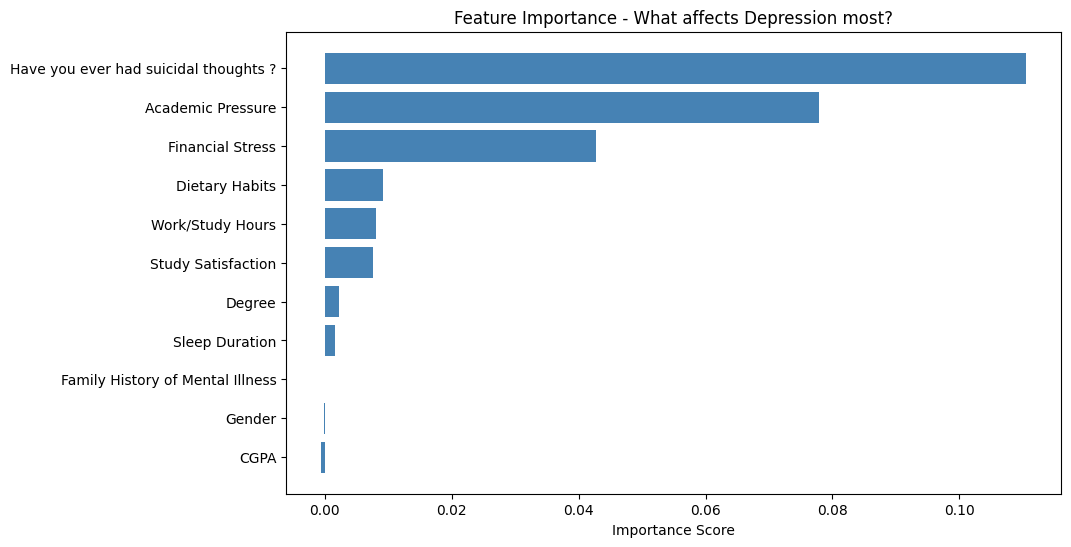

DEPRESSION DISTRIBUTION


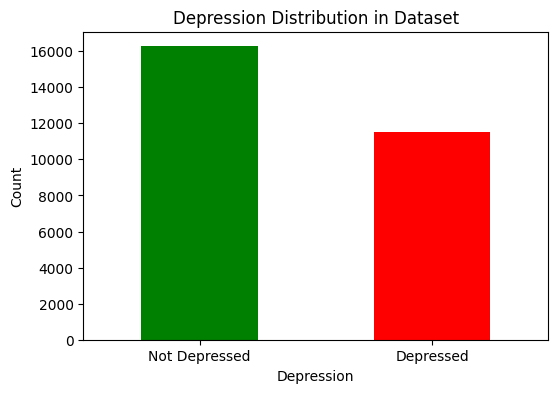

FINANCIAL STRESS VS DEPRESSION


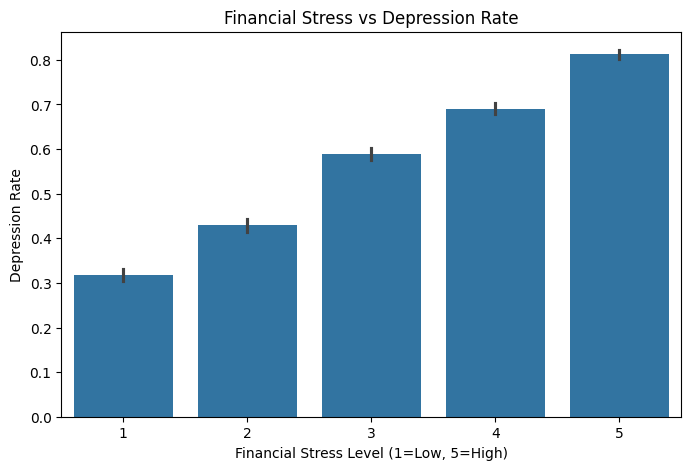

SLEEP DURATION VS DEPRESSION


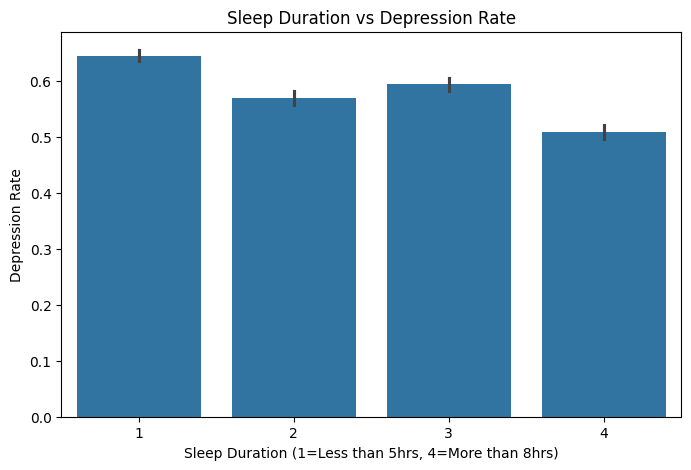

In [ ]:
#wag i run eto yung visualization 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import numpy as np

# VISUALIZATION 1 - CONFUSION MATRIX
print("=" * 50)
print("CONFUSION MATRIX VISUALIZATION")
print("=" * 50)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Not Depressed', 'Depressed'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# VISUALIZATION 2 - MODEL COMPARISON
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
models = ['Logistic Regression', 'Naive Bayes', 'Random Forest']
accuracies = [83.56, 82.98, 82.66]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['green', 'blue', 'orange'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(80, 85)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.05,
             f'{acc}%', ha='center')
plt.show()

# VISUALIZATION 3 - FEATURE IMPORTANCE
print("=" * 50)
print("FEATURE IMPORTANCE")
print("=" * 50)
importance = permutation_importance(model, X_test, y_test, 
                                    random_state=42)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance['importances_mean']
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], 
         feature_importance['Importance'],
         color='steelblue')
plt.title('Feature Importance - What affects Depression most?')
plt.xlabel('Importance Score')
plt.show()

# VISUALIZATION 4 - DEPRESSION DISTRIBUTION
print("=" * 50)
print("DEPRESSION DISTRIBUTION")
print("=" * 50)
plt.figure(figsize=(6, 4))
df['Depression'].value_counts().plot(kind='bar', 
                                      color=['green', 'red'])
plt.title('Depression Distribution in Dataset')
plt.xticks([0, 1], ['Not Depressed', 'Depressed'], rotation=0)
plt.ylabel('Count')
plt.show()

# VISUALIZATION 5 - FINANCIAL STRESS VS DEPRESSION
print("=" * 50)
print("FINANCIAL STRESS VS DEPRESSION")
print("=" * 50)
plt.figure(figsize=(8, 5))
sns.barplot(x='Financial Stress', y='Depression', data=df)
plt.title('Financial Stress vs Depression Rate')
plt.xlabel('Financial Stress Level (1=Low, 5=High)')
plt.ylabel('Depression Rate')
plt.show()

# VISUALIZATION 6 - SLEEP DURATION VS DEPRESSION
print("=" * 50)
print("SLEEP DURATION VS DEPRESSION")
print("=" * 50)
plt.figure(figsize=(8, 5))
sns.barplot(x='Sleep Duration', y='Depression', data=df)
plt.title('Sleep Duration vs Depression Rate')
plt.xlabel('Sleep Duration (1=Less than 5hrs, 4=More than 8hrs)')
plt.ylabel('Depression Rate')
plt.show()



pkl file 
yung csv na file ginawa kong pkl model

In [ ]:
import pickle


# SAVE MODEL AS PICKLE
print("=" * 50)
print("SAVING MODEL AS PICKLE")
print("=" * 50)

with open(r'C:\Users\Zen\OneDrive\Desktop\DepressionPrediction\models\depression_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully!")

# VERIFY - LOAD AND TEST
print("\n" + "=" * 50)
print("VERIFYING PICKLE FILE")
print("=" * 50)

with open(r'C:\Users\Zen\OneDrive\Desktop\DepressionPrediction\models\depression_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)


SAVING MODEL AS PICKLE
Model saved successfully!

VERIFYING PICKLE FILE
Test prediction: [1]
0 = Not Depressed, 1 = Depressed
Pickle file working correctly!
